In [49]:
import numpy as np
import pandas as pd
import pickle
import statsmodels.api as sm
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
from src.model_evaluation import ModelEvaluation


In [10]:
import sys
import os
sys.path.append("..")

In [11]:
with open('D:\PD_MODEL\PARAMS\pd_model.pkl','rb') as f:
    model=pickle.load(f)

with open('D:\PD_MODEL\PARAMS\/woe_binner.pkl', 'rb') as f:
    woe=pickle.load(f)

with open(r'D:\PD_MODEL\PARAMS\final_features.pkl','rb') as f:
    features=pickle.load(f)

In [13]:
from src.data_preprocessing import LoanDataPreprocessor
from src.feature_engineering import apply_feature_engineering
from src.model_validation import backtesting
from src.model_validation import challenger_model
from src.model_validation import sensitivity_analysis
from src.model_validation import stress_simulation

In [14]:
data_processor=LoanDataPreprocessor()
df_oot=data_processor.preprocess('D:\PD_MODEL\DATA\loan_data_2015.csv')
df_oot_fe,feature_cols=apply_feature_engineering(df_oot, None)
df_oot_woe=woe.apply_bins(df_oot_fe)
df_oot_woe=woe.transform(df_oot_woe)

INFO:root:Preprocessing version: v1.0
INFO:root:Cleaning employment length
INFO:root:Cleaning term
INFO:root:dates conversion
INFO:root:credit age creation
INFO:root:missing values handling
INFO:root:target variable creation
INFO:root:Applying outlier capping on 47 columns
INFO:root:final dataset shape: (421094, 80)
INFO:root:Starting feature engineering
INFO:root:Applying categorical grouping
INFO:root:Feature engineering completed. Shape: (421094, 85)
INFO:root:Feature engineering version: v1.0


In [15]:
df_oot_woe.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,initial_list_status_woe,int_rate_bin_woe,dti_bin_woe,annual_inc_bin_woe,installment_bin_woe,delinq_2yrs_bin_woe,inq_last_6mths_bin_woe,credit_age_months_bin_woe,open_acc_bin_woe,total_acc_bin_woe
0,60516983,64537751,20000,20000,20000,36 months,12.29,667.06,C,C1,...,0.223494,0.385109,-0.090694,0.022372,-0.036421,-0.000472,-0.062870,0.018155,0.043296,0.087128
1,60187139,64163931,11000,11000,11000,36 months,12.69,369.00,C,C2,...,0.223494,0.385109,-0.203865,-0.197276,-0.002328,-0.000472,0.195875,-0.107848,-0.003823,0.087128
2,60356453,64333218,7000,7000,7000,36 months,9.99,225.84,B,B3,...,-0.105930,1.052007,-0.203865,-0.197276,0.086846,-0.000472,-0.062870,-0.213277,0.043296,0.087128
3,59955769,63900496,10000,10000,10000,36 months,10.99,327.34,B,B4,...,-0.105930,0.385109,-0.203865,-0.197276,-0.002328,-0.000472,-0.297868,0.018155,0.043296,0.087128
4,58703693,62544456,9550,9550,9550,36 months,19.99,354.87,E,E4,...,0.223494,-0.462954,-0.203865,-0.197276,-0.002328,-0.000472,-0.297868,0.018155,-0.005804,0.033141


In [16]:
print('good_bad' in df_oot.columns)
print('good_bad' in df_oot_fe.columns)
print('good_bad' in df_oot_woe.columns)

True
True
True


In [17]:
print(len(features))

9


In [18]:
missing=set(features)-set(df_oot_woe.columns)
extra=set(df_oot_woe.columns)-set(features)
print('Missing_features',missing)
print('Extra features:', extra)

Missing_features set()
Extra features: {'zip_code', 'int_rate_bin', 'mths_since_last_record_missing', 'verification_status', 'total_pymnt_inv', 'loan_amnt', 'annual_inc_bin', 'title', 'addr_state_grp', 'inq_last_6mths_bin', 'total_pymnt', 'mths_since_last_major_derog', 'max_bal_bc', 'open_il_24m', 'mths_since_rcnt_il', 'purpose', 'il_util', 'out_prncp_inv', 'credit_age_months', 'acc_now_delinq', 'installment_bin_woe', 'desc', 'inq_last_12m', 'total_bal_il', 'dti_bin', 'pub_rec', 'total_acc', 'inq_last_6mths', 'collection_recovery_fee', 'emp_length', 'loan_status', 'addr_state', 'open_acc_bin_woe', 'total_rec_int', 'open_acc', 'installment_bin', 'dti_joint', 'earliest_cr_line', 'all_util', 'open_rv_12m', 'id', 'inq_fi', 'annual_inc', 'delinq_2yrs_bin', 'funded_amnt_inv', 'mths_since_last_delinq_missing', 'tot_coll_amt', 'policy_code', 'initial_list_status', 'last_pymnt_d', 'pymnt_plan', 'installment', 'tot_cur_bal', 'total_acc_bin', 'total_rec_late_fee', 'open_rv_24m', 'revol_bal', 'app

In [19]:
X_oot=df_oot_woe[features]
y_oot=df_oot_woe['good_bad']

In [20]:
print(X_oot.columns)
print(X_oot.shape)
print(y_oot.shape)

Index(['grade_woe', 'inq_last_6mths_bin_woe', 'annual_inc_bin_woe',
       'purpose_woe', 'credit_age_months_bin_woe', 'dti_bin_woe',
       'initial_list_status_woe', 'home_ownership_woe',
       'verification_status_woe'],
      dtype='object')
(421094, 9)
(421094,)


In [21]:
y_pred=model.predict_proba(X_oot)

INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)


In [22]:
bt_results=backtesting(df_oot_woe, y_oot, y_pred)
bt_results

d:\PD_MODEL\Models\..\src\model_validation.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary=df.groupby('decile').agg(


,decile,avg_pd,actual_rate,count
0,"(0.012899999999999998, 0.0313]",0.024731,0.002992,42118
1,"(0.0313, 0.0458]",0.038313,0.004418,42101
2,"(0.0458, 0.0599]",0.053008,0.007693,42116
3,"(0.0599, 0.0726]",0.066286,0.009311,42103
4,"(0.0726, 0.0858]",0.079150,0.012965,42112
5,"(0.0858, 0.101]",0.093239,0.015055,42113
6,"(0.101, 0.12]",0.110122,0.019502,42251
7,"(0.12, 0.144]",0.131288,0.026000,41961
8,"(0.144, 0.181]",0.160922,0.032548,42122
9,"(0.181, 0.52]",0.226477,0.055990,42097


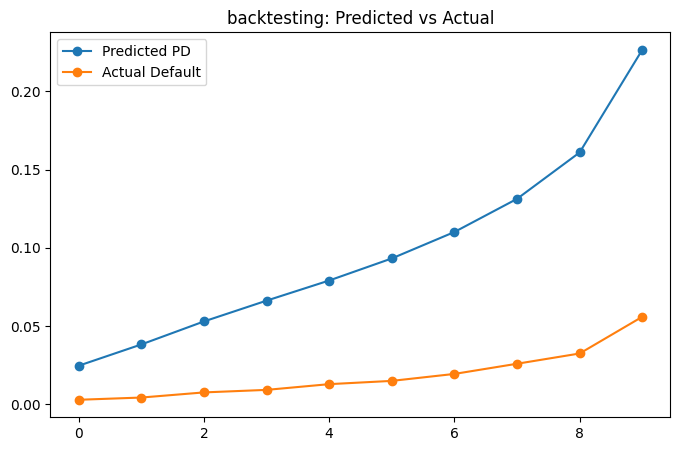

In [23]:
plt.figure(figsize=(8,5))
plt.plot(bt_results['avg_pd'], marker='o', label='Predicted PD')
plt.plot(bt_results['actual_rate'], marker='o', label='Actual Default')
plt.legend()
plt.title('backtesting: Predicted vs Actual')
plt.show()

In [36]:
from src.calibration import PDcalibrator

In [37]:
cal=PDcalibrator()

In [39]:
cal.load('D:\PD_MODEL\PARAMS\calibration_model.pkl')

In [40]:
y_pred=model.predict_proba(X_oot)

INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)


In [41]:
y_pred_cal=cal.predict(y_pred)

In [42]:
bt_results_cal=backtesting(df_oot_woe, y_oot, y_pred_cal)
bt_results_cal

d:\PD_MODEL\Models\..\src\model_validation.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary=df.groupby('decile').agg(


,decile,avg_pd,actual_rate,count
0,"(0.00526, 0.00748]",0.007001,0.002992,42118
1,"(0.00748, 0.00868]",0.008052,0.004418,42101
2,"(0.00868, 0.01]",0.009365,0.007693,42116
3,"(0.01, 0.0114]",0.010732,0.009311,42103
4,"(0.0114, 0.0131]",0.012246,0.012965,42112
5,"(0.0131, 0.0153]",0.014149,0.015055,42113
6,"(0.0153, 0.0185]",0.016821,0.019502,42251
7,"(0.0185, 0.0237]",0.020886,0.026000,41961
8,"(0.0237, 0.0345]",0.028278,0.032548,42122
9,"(0.0345, 0.545]",0.058938,0.055990,42097


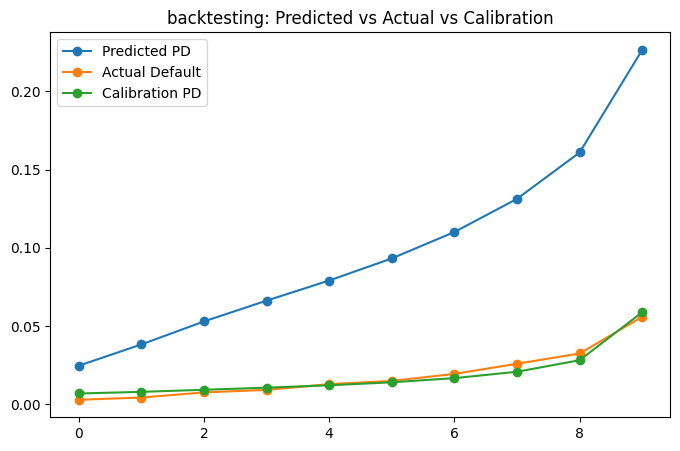

In [43]:
plt.figure(figsize=(8,5))
plt.plot(bt_results['avg_pd'], marker='o', label='Predicted PD')
plt.plot(bt_results['actual_rate'], marker='o', label='Actual Default')
plt.plot(bt_results_cal['avg_pd'], marker='o', label='Calibration PD')
plt.legend()
plt.title('backtesting: Predicted vs Actual vs Calibration')
plt.show()

In [44]:
from sklearn.metrics import brier_score_loss

In [45]:
brier_before=brier_score_loss(y_oot, y_pred)
brier_after_cal=brier_score_loss(y_oot, y_pred_cal)

In [46]:
print("Brier Before:", brier_before)
print("Brier After:", brier_after_cal)

Brier Before: 0.026358677844537857
Brier After: 0.018095280491157408


In [47]:
from sklearn.metrics import roc_auc_score

auc_oot = roc_auc_score(y_oot, y_pred)
auc_cal = roc_auc_score(y_oot, y_pred_cal)

print("AUC (Original):", auc_oot)
print("AUC (Calibrated):", auc_cal)

AUC (Original): 0.7216923443374125
AUC (Calibrated): 0.7216923471114481


In [50]:
eval_model=ModelEvaluation()

In [51]:
eval_model=ModelEvaluation()

In [52]:
# ── OOT KS ───────────────────────────────────────────────────
ks_oot = eval_model.ks(y_oot, y_pred)
gini_oot = eval_model.gini(y_oot, y_pred)

print("=== OOT Validation Metrics ===")
print(f"OOT AUC  : {auc_oot:.4f}")
print(f"OOT Gini : {gini_oot:.4f}")
print(f"OOT KS   : {ks_oot:.4f}")

=== OOT Validation Metrics ===
OOT AUC  : 0.7217
OOT Gini : 0.4434
OOT KS   : 0.3282


In [53]:
X=X_oot.copy()

In [54]:
X.head()

,grade_woe,inq_last_6mths_bin_woe,annual_inc_bin_woe,purpose_woe,credit_age_months_bin_woe,dti_bin_woe,initial_list_status_woe,home_ownership_woe,verification_status_woe
0,-0.056491,-0.062870,0.022372,-0.043086,0.018155,-0.090694,0.223494,0.020963,0.053403
1,-0.056491,0.195875,-0.197276,-0.043086,-0.107848,-0.203865,0.223494,0.146051,0.053403
2,0.373511,-0.062870,-0.197276,-0.043086,-0.213277,-0.203865,-0.105930,0.146051,0.053403
3,0.373511,-0.297868,-0.197276,0.274140,0.018155,-0.203865,-0.105930,0.146051,0.053403
4,-0.675120,-0.297868,-0.197276,-0.043086,0.018155,-0.203865,0.223494,-0.165189,-0.175220


In [55]:
coef=model.get_coefficients()
coef=coef.drop('const', errors='ignore')
top_vars = coef.abs().sort_values(ascending=False).head(4).index.tolist()

In [56]:
top_vars

['initial_list_status_woe',
 'grade_woe',
 'annual_inc_bin_woe',
 'inq_last_6mths_bin_woe']

In [57]:
coef

grade_woe                   -0.853806
inq_last_6mths_bin_woe      -0.578915
annual_inc_bin_woe          -0.739513
purpose_woe                 -0.485932
credit_age_months_bin_woe   -0.505443
dti_bin_woe                 -0.546035
initial_list_status_woe     -0.943361
home_ownership_woe          -0.505080
verification_status_woe     -0.506904
dtype: float64

In [58]:
features_to_test=top_vars

INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)


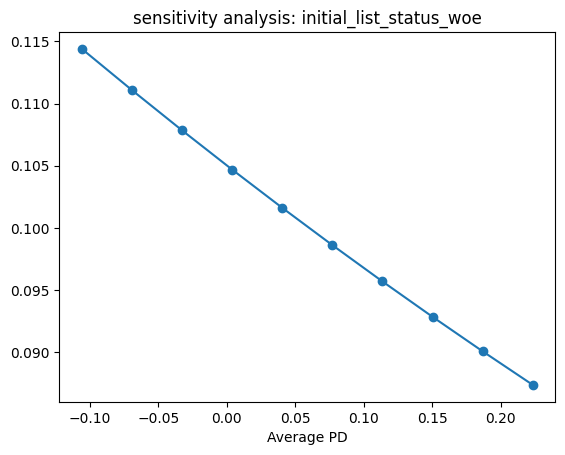

INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)


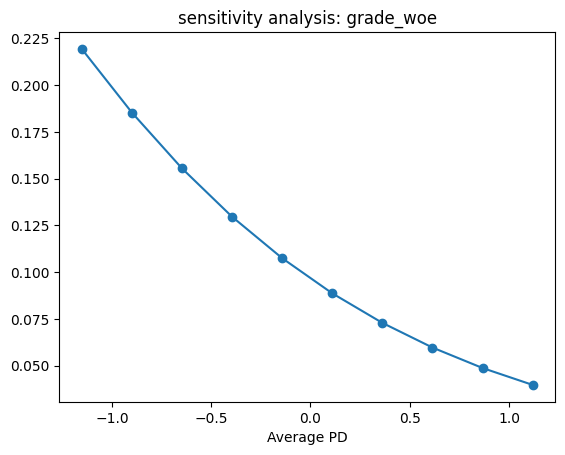

INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)


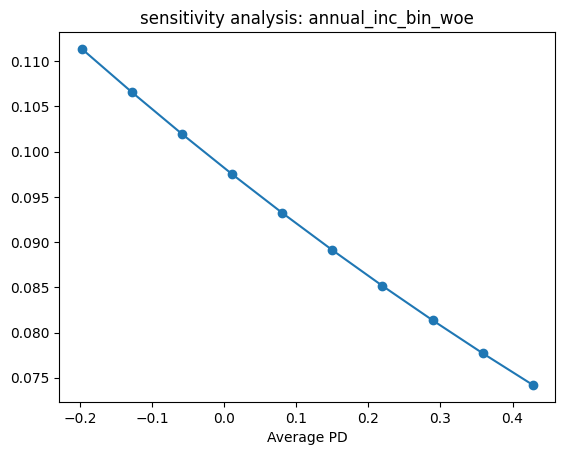

INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)


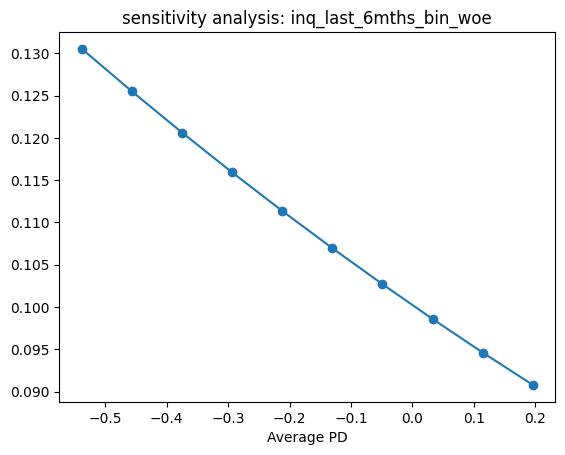

In [59]:
for feature in features_to_test:
    values, avg_pd=sensitivity_analysis(model, X, feature)

    plt.figure()
    plt.plot(values, avg_pd, marker='o')
    plt.title(f'sensitivity analysis: {feature}')
    plt.xlabel('Average PD')
    plt.show()

In [60]:
from src.config import BIN_RULES

In [61]:
raw_stress_pd, cal_stress_pd = stress_simulation(
    df_oot_woe,
    model,
    cal,
    features
)

INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)


In [62]:
print("===== STRESS TEST RESULTS =====")

# Baseline calibrated PD
baseline_pd = y_pred_cal.mean()

# Stressed calibrated PD
stressed_pd = cal_stress_pd.mean()

print(f"Baseline Average PD : {baseline_pd:.4f}")
print(f"Stressed Average PD : {stressed_pd:.4f}")

# Relative increase
increase_pct = (
    (stressed_pd - baseline_pd)
    / baseline_pd
) * 100

print(f"PD Increase (%) : {increase_pct:.2f}%")

# Absolute increase
absolute_increase = stressed_pd - baseline_pd

print(f"Absolute PD Increase : {absolute_increase:.4f}")

===== STRESS TEST RESULTS =====
Baseline Average PD : 0.0186
Stressed Average PD : 0.0188
PD Increase (%) : 0.59%
Absolute PD Increase : 0.0001
